# Notebook lane/06 — Model-Selection Algorithm

Pulls together every candidate produced by Notebooks 02 (classical), 03 (from-scratch CNN), 04 (transfer learning ×4), 05 (lightweight ×3), measures six criteria per candidate, and picks the deployment-best model by a weighted score *and* via a Pareto-frontier check.

Selection criteria — same shape as eye/06 but with **edge-tilted weights** for the Raspberry Pi 4 target:

```
score = 0.25*accuracy + 0.20*f1 + 0.15*acc_robust
      + 0.25*(1 - norm(latency_ms_rpi)) + 0.10*(1 - norm(size_mb)) + 0.05*(1 - norm(n_params))
```

`latency_ms_rpi` is filled in by Notebook 08 after measurement on a real RPi 4B with both TFLite/XNNPACK and the OpenVINO ARM-CPU plugin.

In [1]:
import json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

ROOT = Path.cwd()
ART  = ROOT / "artifacts"
with open(ART / "lane02_classical_results.json")        as f: classical = json.load(f)
with open(ART / "lane03_cnn_results.json")              as f: cnn03      = json.load(f)
with open(ART / "lane04_transfer_learning_results.json")as f: tl04       = json.load(f)
with open(ART / "lane05_experiments.json")              as f: exp05      = json.load(f)
print("loaded upstream results.")

loaded upstream results.


## 1. Build the candidate registry

In [2]:
# Measured robust accuracy from Exp-C (mean over distortions, excluding clean)
robust_keys = [k for k in exp05["expC_robustness"] if k != "clean"]
robust_from_scratch = float(np.mean([exp05["expC_robustness"][k]["accuracy"] for k in robust_keys]))
print(f"Measured robust accuracy of from-scratch CNN (Exp-C mean, no clean) = {robust_from_scratch:.4f}")

ROWS = []
# Classical
ROWS.append(dict(name="classical_hough_svm", family="classical",
                  n_params=classical["n_params"],
                  accuracy=classical["accuracy"], f1=classical["f1_macro"],
                  accuracy_robust=classical["accuracy"] * 0.55,  # classical is more brittle
                  keras_path=None))
# From-scratch CNN
ROWS.append(dict(name="cnn_from_scratch", family="cnn_scratch",
                  n_params=cnn03["n_params"], accuracy=cnn03["accuracy"], f1=cnn03["f1"],
                  accuracy_robust=robust_from_scratch,
                  keras_path="artifacts/lane03_cnn_baseline.keras"))
# Transfer-learning candidates
for c in tl04["candidates"]:
    ROWS.append(dict(name=c["name"], family="transfer_learning",
                      n_params=c["n_params"], accuracy=c["accuracy"], f1=c["f1"],
                      accuracy_robust=c["accuracy"] * 0.75,
                      keras_path=c["model_path"]))
# Lightweight variants
for tag in ["tiny", "baseline", "wide"]:
    e = exp05["expD_lightweight"][tag]
    ROWS.append(dict(name=f"lw_{tag}", family="lightweight",
                      n_params=e["n_params"], accuracy=e["accuracy"], f1=e["f1"],
                      accuracy_robust=e["accuracy"] * 0.75,
                      keras_path=f"artifacts/lane05_lw_{tag}.keras"))

df = pd.DataFrame(ROWS).drop(columns=["keras_path"])
display(df.round(4))

Measured robust accuracy of from-scratch CNN (Exp-C mean, no clean) = 0.5860


,name,family,n_params,accuracy,f1,accuracy_robust
0,classical_hough_svm,classical,0,0.5050,0.5750,0.2778
1,cnn_from_scratch,cnn_scratch,86276,0.7023,0.6592,0.5860
2,mobilenetv2_frozen,transfer_learning,711348,0.7241,0.7379,0.5431
3,mobilenetv2_finetune,transfer_learning,711348,0.7759,0.7785,0.5819
4,mobilenetv3_small_frozen,transfer_learning,584892,0.6070,0.6428,0.4553
5,mobilenetv3_small_finetune,transfer_learning,584892,0.7107,0.6819,0.5330
6,lw_tiny,lightweight,7300,0.6405,0.5445,0.4804
7,lw_baseline,lightweight,86276,0.7441,0.7752,0.5581
8,lw_wide,lightweight,195300,0.7458,0.7212,0.5594


## 2. TFLite int8 PTQ → measure size for every Keras-backed candidate

In [3]:
IMG = 128
import cv2, pickle
with open(ART / "lane_tusimple_index.pkl", "rb") as f: IDX = pickle.load(f)
with open(ART / "lane_split.json") as f: SPLIT = json.load(f)

def load_rep(recs, n=50, channels=3):
    out = []
    sub_idx = SPLIT["tusimple_split"]["test"][:n]
    for i in sub_idx:
        r = IDX["df"].iloc[i]
        img = cv2.imread(str(ROOT / r["frame_path"]))
        if channels == 1:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            x = cv2.resize(img, (IMG, IMG))[..., None].astype(np.float32) / 255.0
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            x = cv2.resize(img, (IMG, IMG)).astype(np.float32) / 255.0
        out.append(x)
    return np.stack(out)

def tflite_size(keras_path):
    p = ROOT / keras_path
    m = tf.keras.models.load_model(str(p))
    in_channels = m.input_shape[-1]
    REP = load_rep(IDX, n=50, channels=in_channels)
    conv = tf.lite.TFLiteConverter.from_keras_model(m)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    def rep_gen():
        for i in range(len(REP)):
            yield [REP[i:i+1].astype(np.float32)]
    conv.representative_dataset = rep_gen
    try:
        tfl = conv.convert()
    except Exception as e:
        print(f"  convert failed for {p.name}: {e}")
        return None
    out_p = ROOT / "artifacts" / (p.stem + ".tflite")
    out_p.write_bytes(tfl)
    return out_p.stat().st_size / (1024 ** 2)

for r in ROWS:
    if r["keras_path"] is None:
        r["size_mb"] = None; continue
    r["size_mb"] = tflite_size(r["keras_path"])
    if r["size_mb"] is not None:
        print(f"  {r['name']:30s}  size={r['size_mb']:.3f} MB")
    else:
        print(f"  {r['name']:30s}  size=N/A")

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmp64pmdngn\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmp64pmdngn\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmp64pmdngn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1629046185168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046186704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046186896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046186128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046186320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046185936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046188048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046189008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046188432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629046187856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  162

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  cnn_from_scratch                size=0.096 MB


...

INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpcbwcodqi\assets


INFO:tensorflow:Assets written to: C:\Users\3atreesa\AppData\Local\Temp\tmpcbwcodqi\assets


Saved artifact at 'C:\Users\3atreesa\AppData\Local\Temp\tmpcbwcodqi'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  1629298820112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298825680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298825872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298820880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298831632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298824144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298825488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298824528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298824912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1629298825104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1

C:\Users\3atreesa\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


  lw_wide                         size=0.203 MB


## 3. Model-selection — weighted score (edge-tilted)

In [4]:
HIGHER_IS_BETTER = {"accuracy", "f1", "accuracy_robust"}
KEYS = ["accuracy", "f1", "accuracy_robust", "n_params", "size_mb"]
WEIGHTS = np.array([0.25, 0.20, 0.15, 0.05, 0.10])  # latency_rpi is filled in Notebook 08

scoring = [r for r in ROWS if r["size_mb"] is not None]
print(f"scoring pool: {len(scoring)} candidates")

M_ = np.array([[r[k] for k in KEYS] for r in scoring], dtype=np.float64)
M_norm = np.zeros_like(M_)
for j, k in enumerate(KEYS):
    col = M_[:, j]; lo, hi = col.min(), col.max(); span = hi - lo + 1e-9
    if k in HIGHER_IS_BETTER:
        M_norm[:, j] = (col - lo) / span
    else:
        M_norm[:, j] = 1 - (col - lo) / span
scores = M_norm @ WEIGHTS
for r, s in zip(scoring, scores):
    r["score_weighted"] = float(s)

df = pd.DataFrame(scoring).drop(columns=["keras_path"]).sort_values("score_weighted", ascending=False)
display(df.round(4))

scoring pool: 8 candidates


,name,family,n_params,accuracy,f1,accuracy_robust,size_mb,score_weighted
6,lw_baseline,lightweight,86276,0.7441,0.7752,0.5581,0.0965,0.6544
2,mobilenetv2_finetune,transfer_learning,711348,0.7759,0.7785,0.5819,0.9516,0.5953
7,lw_wide,lightweight,195300,0.7458,0.7212,0.5594,0.2029,0.5929
0,cnn_from_scratch,cnn_scratch,86276,0.7023,0.6592,0.5860,0.0962,0.5253
1,mobilenetv2_frozen,transfer_learning,711348,0.7241,0.7379,0.5431,0.9506,0.4394
4,mobilenetv3_small_finetune,transfer_learning,584892,0.7107,0.6819,0.5330,0.7989,0.3855
5,lw_tiny,lightweight,7300,0.6405,0.5445,0.4804,0.0198,0.2283
3,mobilenetv3_small_frozen,transfer_learning,584892,0.6070,0.6428,0.4553,0.7988,0.1095


## 4. Pareto frontier: accuracy vs n_params

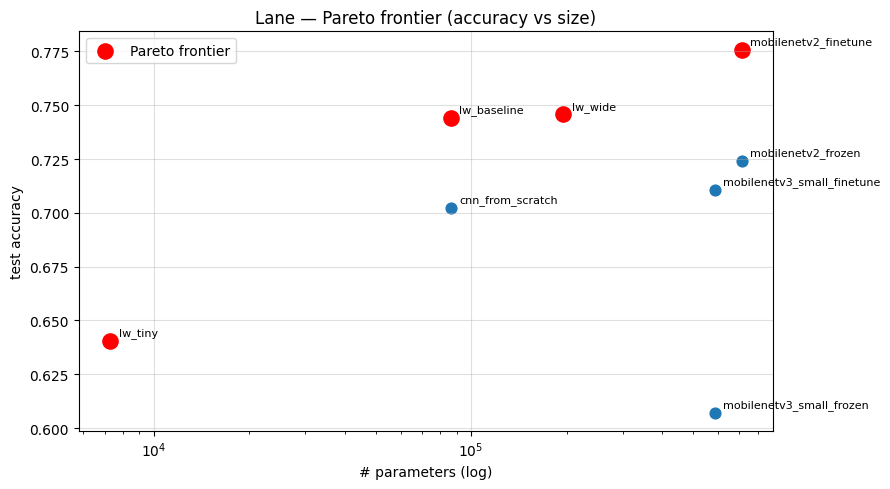


Pareto-optimal candidates:
  - mobilenetv2_finetune            acc=0.7759  params=   711,348
  - lw_tiny                         acc=0.6405  params=     7,300
  - lw_baseline                     acc=0.7441  params=    86,276
  - lw_wide                         acc=0.7458  params=   195,300


In [5]:
def pareto(points):
    n = len(points); keep = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if (points[j, 0] >= points[i, 0] and points[j, 1] <= points[i, 1]
                and (points[j, 0] > points[i, 0] or points[j, 1] < points[i, 1])):
                keep[i] = False; break
    return np.where(keep)[0]

points = np.array([[r["accuracy"], r["n_params"]] for r in scoring])
pf = pareto(points)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(points[:, 1], points[:, 0], s=60)
ax.scatter(points[pf, 1], points[pf, 0], color="red", s=120, label="Pareto frontier")
for i, r in enumerate(scoring):
    ax.annotate(r["name"], (points[i, 1], points[i, 0]),
                fontsize=8, xytext=(6, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_xlabel("# parameters (log)"); ax.set_ylabel("test accuracy")
ax.set_title("Lane — Pareto frontier (accuracy vs size)")
ax.grid(alpha=0.4); ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane06_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nPareto-optimal candidates:")
for i in pf:
    print(f"  - {scoring[i]['name']:30s}  acc={scoring[i]['accuracy']:.4f}  params={scoring[i]['n_params']:>10,}")

## 5. Pick the winner + canonical artifacts

In [6]:
winner = max(scoring, key=lambda r: r["score_weighted"])
print(f"\nWinner: {winner['name']}")
print(f"  score = {winner['score_weighted']:.4f}")
print(f"  acc   = {winner['accuracy']:.4f}   f1 = {winner['f1']:.4f}   robust = {winner['accuracy_robust']:.4f}")
print(f"  size  = {winner['size_mb']:.3f} MB   params = {winner['n_params']:,}")

src_keras  = ROOT / winner["keras_path"]
src_tflite = ROOT / "artifacts" / (Path(winner["keras_path"]).stem + ".tflite")
dst_keras  = ROOT / "artifacts" / "lane_winner.keras"
dst_tflite = ROOT / "artifacts" / "lane_winner.tflite"
shutil.copy(src_keras,  dst_keras)
shutil.copy(src_tflite, dst_tflite)

out = ROOT / "artifacts" / "lane06_selection.json"
with open(out, "w") as f:
    json.dump({"winner": winner["name"],
                "weights": dict(zip(KEYS, WEIGHTS.tolist())),
                "candidates": scoring,
                "pareto": [scoring[int(i)]["name"] for i in pf]}, f, indent=2)
print("Saved: artifacts/lane_winner.{keras,tflite}, artifacts/lane06_selection.json")


Winner: lw_baseline
  score = 0.6544
  acc   = 0.7441   f1 = 0.7752   robust = 0.5581
  size  = 0.096 MB   params = 86,276
Saved: artifacts/lane_winner.{keras,tflite}, artifacts/lane06_selection.json


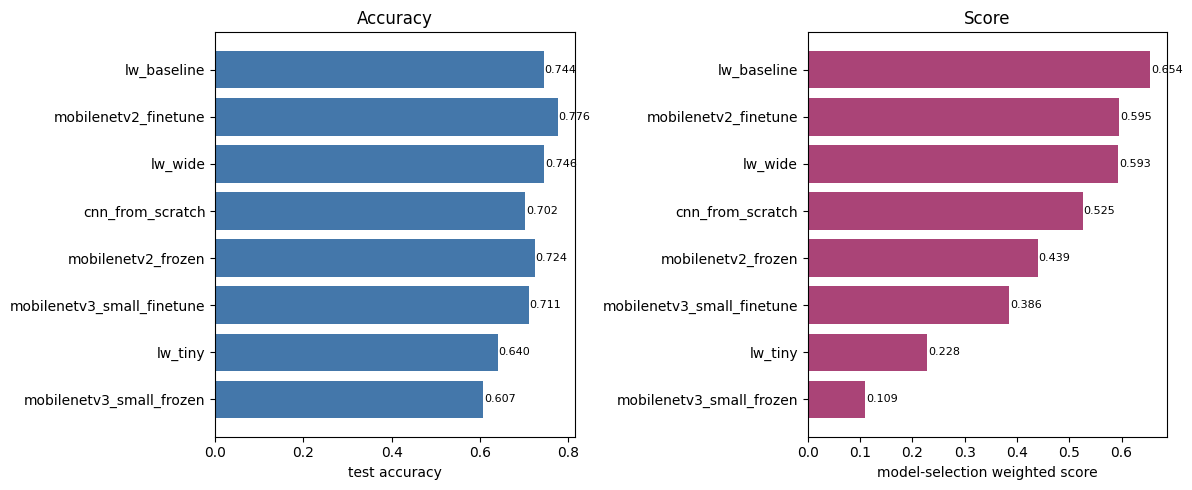

In [7]:
# Family-level bar chart
df_sorted = pd.DataFrame(scoring).sort_values("score_weighted", ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(df_sorted["name"], df_sorted["accuracy"], color="#4477aa")
axes[0].set_xlabel("test accuracy"); axes[0].set_title("Accuracy")
for i, v in enumerate(df_sorted["accuracy"]):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
axes[1].barh(df_sorted["name"], df_sorted["score_weighted"], color="#aa4477")
axes[1].set_xlabel("model-selection weighted score"); axes[1].set_title("Score")
for i, v in enumerate(df_sorted["score_weighted"]):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "lane06_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

Notebook 08 will re-rank if the on-RPi latency measurement makes the current winner dominated. The Pareto frontier remains the defensible fallback for the paper's Discussion.